In [1]:
import sys
# !{sys.executable} -m pip install gdown h5py

In [2]:
from utils import load_it_data, visualize_img
import matplotlib.pyplot as plt
import numpy as np

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder

In [4]:
from scipy.stats import pearsonr
from sklearn.metrics import explained_variance_score

In [5]:
!pip install timm

In [5]:
import torch
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets,transforms
from torch.utils.data import DataLoader, TensorDataset
import timm
from sklearn.metrics import r2_score
from PIL import Image

In [6]:
from sklearn.decomposition import PCA
#from skopt import BayesSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

## Load the data

In [7]:
path_to_data = "/home/nsuresh/NX-414_groupSRN/Week 7/" ## Insert the folder where the data is, if you download in the same folder as this notebook then leave it blank

stimulus_train, stimulus_val, stimulus_test, objects_train, objects_val, objects_test, spikes_train, spikes_val = load_it_data(path_to_data)

In [8]:
print("stimulus_train shape: ", stimulus_train.shape)
print("stimulus_val shape: ", stimulus_val.shape)
print("stimulus_test shape: ", stimulus_val.shape)
print("objects_train shape: ", len(objects_train))
print("objects_val shape: ", len(objects_val))
print("objects_test shape: ", len(objects_test))
print("spikes_train shape: ", spikes_train.shape)
print("spikes_val shape: ", spikes_val.shape)

stimulus_train shape:  (2592, 3, 224, 224)
stimulus_val shape:  (288, 3, 224, 224)
stimulus_test shape:  (288, 3, 224, 224)
objects_train shape:  2592
objects_val shape:  288
objects_test shape:  320
spikes_train shape:  (2592, 168)
spikes_val shape:  (288, 168)


In [9]:
def get_category(label):
    if 'face' in label:
        return 'face'
    elif 'table' in label:
        return 'table'
    elif 'ship' in label:
        return 'boat'
    elif 'car' in label:
        return 'car'
    elif 'chair' in label:
        return 'chair'
    elif 'airplane' in label:
        return 'plane'
    elif label in ['cow', 'lioness', 'dog', 'gorilla', 'turtle', 'elephant', 'hedgehog', 'bear']:  # animals
        return 'animal'
    elif label in ['watermelon', 'walnut', 'raspberry', 'pear', 'peach', 'apricot', 'apple', 'strawberry']:  # fruits
        return 'fruit'
    else:
        return 'unknown'
    
y_classes = [get_category(obj) for obj in objects_train]

In [10]:
y_classes_pair = [(obj,get_category(obj)) for obj in objects_train]
print(y_classes_pair.count("unknown"))
print(y_classes_pair)

others = [obj for obj in objects_train if get_category(obj) == 'unknown']
print(set(others))

0
[('face6', 'face'), ('table3', 'table'), ('face3', 'face'), ('face2', 'face'), ('lioness', 'animal'), ('turtle', 'animal'), ('turtle', 'animal'), ('airplane3', 'plane'), ('cow', 'animal'), ('car_alfa', 'car'), ('table2', 'table'), ('ship1', 'boat'), ('car_bora', 'car'), ('airplane3', 'plane'), ('face6', 'face'), ('chair4', 'chair'), ('airplane0', 'plane'), ('airplane6', 'plane'), ('chair2', 'chair'), ('car_alfa', 'car'), ('gorilla', 'animal'), ('chair4', 'chair'), ('raspberry', 'fruit'), ('pear', 'fruit'), ('chair5', 'chair'), ('face0', 'face'), ('table5', 'table'), ('table1', 'table'), ('airplane5', 'plane'), ('airplane2', 'plane'), ('table7', 'table'), ('chair0', 'chair'), ('chair7', 'chair'), ('face7', 'face'), ('car_beetle', 'car'), ('ship7', 'boat'), ('table0', 'table'), ('chair7', 'chair'), ('airplane4', 'plane'), ('car_z3', 'car'), ('chair7', 'chair'), ('lioness', 'animal'), ('table5', 'table'), ('walnut', 'fruit'), ('chair5', 'chair'), ('chair4', 'chair'), ('chair3', 'chair')

In [11]:
y_classes_val = [get_category(obj) for obj in objects_val]

In [12]:
n_stimulus, n_channels, img_size, _ = stimulus_train.shape
print(_)
_, n_neurons = spikes_train.shape
# print(_)
print('The train dataset contains {} stimuli and {} IT neurons'.format(n_stimulus,n_neurons))
print('Each stimulus have {} channgels (RGB)'.format(n_channels))
print('The size of the image is {}x{}'.format(img_size,img_size))

224
The train dataset contains 2592 stimuli and 168 IT neurons
Each stimulus have 3 channgels (RGB)
The size of the image is 224x224


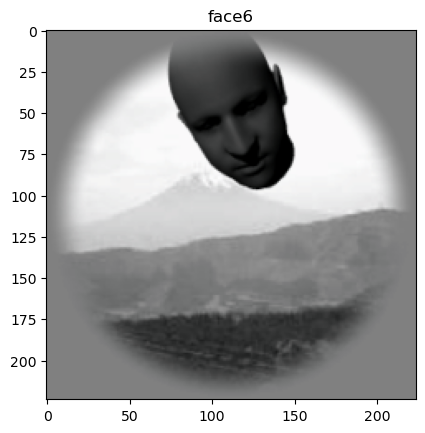

In [13]:
stim_idx = 0

visualize_img(stimulus_train,objects_train,stim_idx)

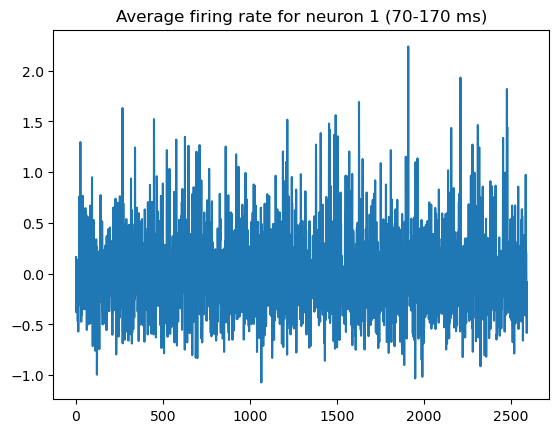

In [14]:
neuron_idx = 1

plt.figure()
plt.title('Average firing rate for neuron {} (70-170 ms)'.format(neuron_idx))
plt.plot(spikes_train[:,neuron_idx])

In [16]:
spikes_train.shape

(2592, 168)

In [15]:
num_classes = len(np.unique(y_classes))
num_classes

8

## Multi-task model using ResNet

In [16]:
from torch.utils.data import Dataset
from PIL import Image
import torch

class MultiTaskDataset(Dataset):
    def __init__(self, stimuli, spikes, classes):
        self.stimuli = stimuli
        self.spikes = spikes
        self.classes = classes

    def __len__(self):
        return len(self.stimuli)

    def __getitem__(self, idx):
        # Load image
        img = self.stimuli[idx]

        spike_target = torch.tensor(self.spikes[idx], dtype=torch.float32)
        class_label = torch.tensor(self.classes[idx], dtype=torch.long)

        return img, spike_target, class_label


In [17]:
label_encoder = LabelEncoder()
encoded_classes = label_encoder.fit_transform(y_classes)
encoded_classes_val = label_encoder.transform(y_classes_val)

In [18]:
train_dataset = MultiTaskDataset(
    stimuli=stimulus_train,
    spikes=spikes_train,
    classes=encoded_classes,
)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

val_dataset = MultiTaskDataset(
    stimuli=stimulus_val,
    spikes=spikes_val,
    classes=encoded_classes_val,
)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

In [19]:
class multitaskNet(nn.Module):
    def __init__(self, resnet):
        super(multitaskNet, self).__init__()
        self.res = resnet
        # for param in self.res.parameters():
        #     param.requires_grad = False
        self.features = nn.Sequential(
            self.res.conv1,
            self.res.bn1,
            self.res.relu,
            self.res.maxpool,
            self.res.layer1,
            self.res.layer2,
            self.res.layer3  # <-- extract activations from here
        )

        # Get number of output channels from layer3
        dummy_input = torch.randn(1, 3, 224, 224)
        out = self.features(dummy_input)
        c, h, w = out.shape[1:]
        flattened = c * h * w

        # MLP to process the features into spike train
        self.spike_predictor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened, 168),
            #nn.Tanh(),
            #nn.Linear(512, 168)
        )

        self.classifier_head = nn.Sequential(
        nn.AdaptiveAvgPool2d((1, 1)),
        nn.Flatten(),
        nn.Linear(resnet.fc.in_features, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        spikes = self.spike_predictor(x)
        cls_input = self.res.layer4(x)
        class_logits =  self.classifier_head(cls_input)
        return spikes, class_logits

In [20]:
alphas = [0.2*(0.5**i) for i in range(20)] #define a range of alphas as geometric progression
alphas.reverse()
val_corrs = []
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
for alpha in alphas:
    print(f"ALPHA={alpha}")

    resnet = models.resnet50(pretrained=True)
    #resnet.eval()  # set to evaluation mode

    model = multitaskNet(resnet).to(device)
    spike_criterion = nn.MSELoss()
    class_criterion = nn.CrossEntropyLoss()
    #optimizer = optim.Adam(model.spike_predictor.parameters(), lr=1e-3, weight_decay=1e-4)
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    num_epochs = 50

    best_model = model.state_dict()
    best_epoch = 1
    best_score = 1

    for epoch in range(num_epochs):
        #Training
        model.train()
        total_train_loss = 0
        for images, spike_targets,class_labels in train_loader:
            images = images.to(device)
            spike_targets = spike_targets.to(device)         # shape: (batch_size, 168)
            class_labels = class_labels.to(device).long()

            optimizer.zero_grad()
            predicted_spikes, class_logits = model(images)
            loss_spike = spike_criterion(predicted_spikes, spike_targets)
            loss_class = class_criterion(class_logits, class_labels)
            total_loss = loss_spike + alpha*loss_class
            total_loss.backward()
            optimizer.step()

            total_train_loss += total_loss.item()

        avg_train_loss = total_train_loss / len(train_loader)

        #Validation
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for images,spike_targets,class_labels in val_loader:
                images = images.to(device)
                spike_targets = spike_targets.to(device)
                class_labels = class_labels.to(device)
                predicted_spikes, class_logits = model(images)
                loss_spike = spike_criterion(predicted_spikes, spike_targets)
                loss_class = class_criterion(class_logits, class_labels)
                total_loss = loss_spike + loss_class
                total_val_loss += total_loss.item()

        avg_val_loss = total_val_loss / len(val_loader)

        if avg_val_loss<best_score:
            best_model = model.state_dict()
            best_epoch = epoch + 1
            best_score = avg_val_loss
        #print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        
        scheduler.step()

    print(f"Best epoch {best_epoch} | Lowest validation loss: {best_score:.4f}")

        #checking correlations with true neural activity using the best model

    model.load_state_dict(best_model)
    model.eval()
    val_all = None 
    y_all = None

    with torch.no_grad():
        for images,spike_targets,class_labels in val_loader:
            images = images.to(device)
            spike_targets = spike_targets.to(device)
            class_labels = class_labels.to(device)
            predicted_spikes, class_logits = model(images)
            val_np = predicted_spikes.detach().cpu().numpy()
            y_np = spike_targets.detach().cpu().numpy()
            if val_all is None:
                val_all = val_np
                y_all = y_np
            else:
                val_all = np.concatenate((val_all,val_np),axis=0)
                y_all = np.concatenate((y_all,y_np),axis=0)

    correlations = []
    for i in range(y_all.shape[1]):
        corr, _ = pearsonr(y_all[:, i], val_all[:, i])
        correlations.append(corr)
    avg_corr_val = np.mean(correlations)

    ev_val = explained_variance_score(y_all, val_all)

    val_corrs.append(avg_corr_val)
    print(f"Avg correlation of validation outputs and ground truth for the best model = {avg_corr_val}")
    print(f"Explained variance of validation outputs and ground truth for the best model = {ev_val}")


ALPHA=3.814697265625e-07


/home/nsuresh/miniconda3/envs/nx414/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/nsuresh/miniconda3/envs/nx414/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


RuntimeError: CUDA error: an illegal instruction was encountered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


ValueError: x and y must have same first dimension, but have shapes (20,) and (0,)

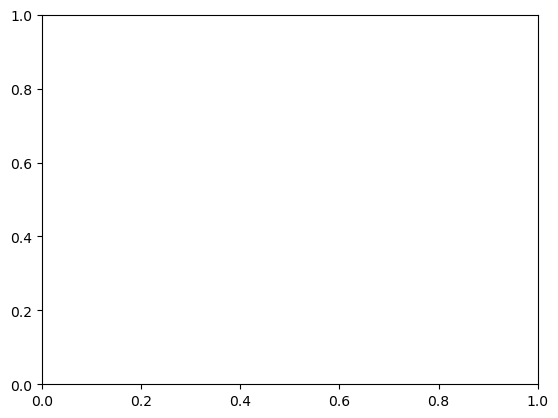

In [21]:
plt.plot(alphas,val_corrs)
plt.xlabel("Alpha")
plt.xscale("log")
plt.ylabel("Correlation between predicted and ground truth")

In [ ]:
#train the CNN in predicting 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resnet = models.resnet50(pretrained=True)
#resnet.eval()  # set to evaluation mode

model = multitaskNet(resnet).to(device)
spike_criterion = nn.MSELoss()
class_criterion = nn.CrossEntropyLoss()
#optimizer = optim.Adam(model.spike_predictor.parameters(), lr=1e-3, weight_decay=1e-4)
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

num_epochs = 50

best_model = model.state_dict()
best_epoch = 1
best_score = 1

alphas = 0.1

for epoch in range(num_epochs):
    #Training
    model.train()
    total_train_loss = 0
    for images, spike_targets,class_labels in train_loader:
        images = images.to(device)
        spike_targets = spike_targets.to(device)         # shape: (batch_size, 168)
        class_labels = class_labels.to(device).long()

        optimizer.zero_grad()
        predicted_spikes, class_logits = model(images)
        loss_spike = spike_criterion(predicted_spikes, spike_targets)
        loss_class = class_criterion(class_logits, class_labels)
        total_loss = loss_spike + alpha*loss_class
        total_loss.backward()
        optimizer.step()

        total_train_loss += total_loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    #Validation
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for images,spike_targets,class_labels in val_loader:
            images = images.to(device)
            spike_targets = spike_targets.to(device)
            class_labels = class_labels.to(device)
            predicted_spikes, class_logits = model(images)
            loss_spike = spike_criterion(predicted_spikes, spike_targets)
            loss_class = class_criterion(class_logits, class_labels)
            total_loss = loss_spike + loss_class
            total_val_loss += total_loss.item()

    avg_val_loss = total_val_loss / len(val_loader)

    if avg_val_loss<best_score:
        best_model = model.state_dict()
        best_epoch = epoch + 1
        best_score = avg_val_loss
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    scheduler.step()

print(f"Best epoch {best_epoch} | Lowest validation loss: {best_score:.4f}")


/home/nsuresh/miniconda3/envs/nx414/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/nsuresh/miniconda3/envs/nx414/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/50 | Train Loss: 0.1263 | Val Loss: 0.1581
Epoch 2/50 | Train Loss: 0.0473 | Val Loss: 0.0990
Epoch 3/50 | Train Loss: 0.0221 | Val Loss: 0.0894
Epoch 4/50 | Train Loss: 0.0121 | Val Loss: 0.0853
Epoch 5/50 | Train Loss: 0.0105 | Val Loss: 0.1749
Epoch 6/50 | Train Loss: 0.0122 | Val Loss: 0.1832
Epoch 7/50 | Train Loss: 0.0117 | Val Loss: 0.0897


KeyboardInterrupt: 

In [ ]:
torch.save(best_model,'multitask_model.pth')

In [ ]:
#checking correlations with true neural activity using the best model

model.load_state_dict(best_model)
model.eval()
val_all = None 
y_all = None

with torch.no_grad():
    for images,spike_targets,class_labels in val_loader:
        images = images.to(device)
        spike_targets = spike_targets.to(device)
        class_labels = class_labels.to(device)
        predicted_spikes, class_logits = model(images)
        val_np = predicted_spikes.detach().cpu().numpy()
        y_np = spike_targets.detach().cpu().numpy()
        if val_all is None:
            val_all = val_np
            y_all = y_np
        else:
            val_all = np.concatenate((val_all,val_np),axis=0)
            y_all = np.concatenate((y_all,y_np),axis=0)

correlations = []
for i in range(y_all.shape[1]):
    corr, _ = pearsonr(y_all[:, i], val_all[:, i])
    correlations.append(corr)
avg_corr_val = np.mean(correlations)

ev_val = explained_variance_score(y_all, val_all)

print(f"Avg correlation of validation outputs and ground truth for the best model = {avg_corr_val}")
print(f"Explained variance of validation outputs and ground truth for the best model = {ev_val}")


Avg correlation of validation outputs and ground truth for the best model = 0.6312015056610107
Explained variance of validation outputs and ground truth for the best model = 0.4022862911224365


Mean correlation : 0.6043229699134827


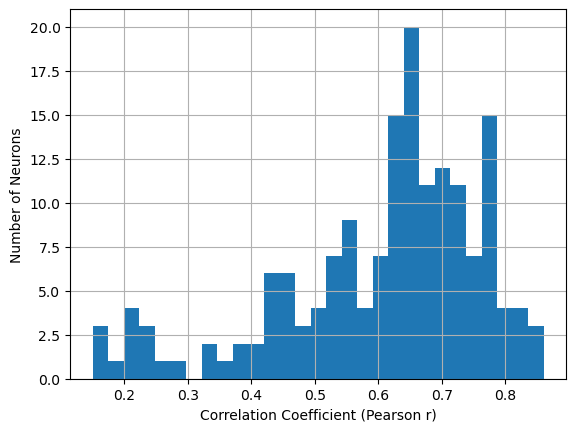

In [38]:
cor_per_neuron = np.array([pearsonr(y_all[:, i], val_all[:, i])[0] for i in range(val_all.shape[1])])
print(f"Mean correlation : {np.mean(cor_per_neuron)}")
    
bins = np.linspace(np.min(cor_per_neuron), np.max(cor_per_neuron), 30)
    
plt.hist(cor_per_neuron, bins=bins)
plt.xlabel('Correlation Coefficient (Pearson r)')
plt.ylabel('Number of Neurons')
plt.grid(True)
plt.show()

Mean explained variance : 0.3582562208175659


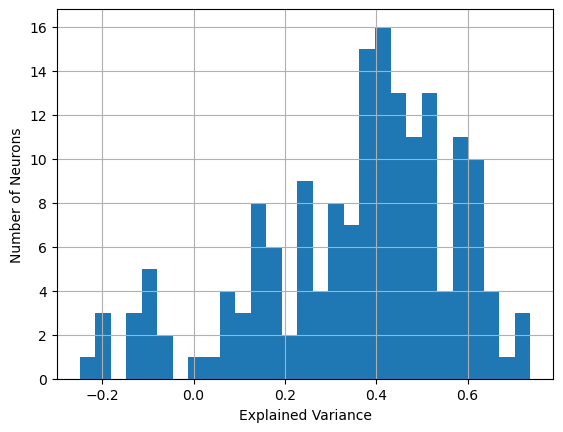

In [39]:
ev_per_neuron = np.array([explained_variance_score(y_all[:, i], val_all[:, i],multioutput='raw_values') for i in range(val_all.shape[1])])
print(f"Mean explained variance : {np.mean(ev_per_neuron)}")
    
bins = np.linspace(np.min(ev_per_neuron), np.max(ev_per_neuron), 30)
    
plt.hist(ev_per_neuron, bins=bins)
plt.xlabel('Explained Variance')
plt.ylabel('Number of Neurons')
plt.grid(True)
plt.show()

## Swin based

In [ ]:
rr_pca_layer4 = Ridge(alpha=85376.71880868787).fit(X_pca_layer4, spikes_train)
rr_y_pred_layer4 = rr_pca_layer4.predict(X_pca_layer4_val)

In [19]:
stimulus_train.shape

(2592, 3, 224, 224)

In [20]:
#Creating DataLoaders
stimulus_train = torch.tensor(stimulus_train, dtype=torch.float32)
spikes_train = torch.tensor(spikes_train, dtype=torch.float32)

stimulus_val = torch.tensor(stimulus_val, dtype=torch.float32)
spikes_val = torch.tensor(spikes_val, dtype=torch.float32)

stimulus_test = torch.tensor(stimulus_test, dtype=torch.float32)

train_dataset = TensorDataset(stimulus_train, spikes_train)
val_dataset = TensorDataset(stimulus_val, spikes_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

In [ ]:
import torch
import torch.nn as nn
import timm
import numpy as np
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from torchvision import transforms
from PIL import Image
# --- Step 1: Load Pretrained Swin Transformer ---
model = timm.create_model('swin_base_patch4_window7_224', pretrained=True)
model.eval()

# Send to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# --- Step 2: Register Hooks to Extract Layer Activations ---
activations = {}

def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

# Choose a block — e.g., last block in stage 2
model.layers[1].blocks[-1].register_forward_hook(get_activation("swin_stage2_block"))

# --- Step 3: Run Image Through the Model and Extract Features ---
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])


# Dummy input image (replace with your actual dataset images)
img = Image.open("your_image.jpg").convert("RGB")  # Replace with real image
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])
x = transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    _ = model(x)

# Get and reshape the activations
feat = activations["swin_stage2_block"]  # shape: [1, num_patches, dim]
feat = feat.squeeze(0).cpu().numpy()     # [num_patches, dim]
flattened = feat.reshape(-1)             # flatten if needed

# Optional: stack multiple images if you have a dataset
# data_matrix = np.stack([...], axis=0)  # shape [n_samples, n_features]

# --- Step 4: PCA + Ridge ---
# PCA
pca = PCA(n_components=100)
X_pca = pca.fit_transform(flattened.reshape(1, -1))  # reshape if just one image

# Ridge
ridge = Ridge(alpha=1.0)
y_target = np.random.randn(1, 168)  # Replace with your spike train
ridge.fit(X_pca, y_target)
y_pred = ridge.predict(X_pca)

# Evaluation (if you have multiple samples)
# score = r2_score(y_true, y_pred)
